In [92]:
import numpy as np
import pylab as plt

E = 1
B = 1
qm = 1

def lorentz_acceleration(velocity: np.ndarray) -> np.ndarray:
    acceleration = qm * np.array([velocity[1] * B, E - velocity[0] * B])
    return acceleration

def deriv(state: np.ndarray) -> np.ndarray:
    derivatives = np.concatenate([state[2:], lorentz_acceleration(state[2:])])
    return derivatives

def initialize_parameters(num_time: int = 1_000, total_time: float = 50):
    time_array = np.linspace(0, total_time, num_time)

    z0 = np.array([0, 0], dtype=float) # initial position
    v0 = np.array([0, 0], dtype=float) # initial velocity

    state0 = np.concatenate([z0, v0])

    return state0, time_array

def forward_euler(state: np.ndarray, interval: float) -> np.ndarray:
    state += deriv(state) * interval
    return state

def backwards_euler(state: np.ndarray, interval: float) -> np.ndarray:
    state_prime = state + deriv(state) * interval
    state += deriv(state_prime) * interval
    return state

def midpoint(state: np.ndarray, interval: float) -> np.ndarray:
    state_prime = state + deriv(state) * interval / 2
    state += (deriv(state) + deriv(state_prime)) * interval / 2
    return state

def leapfrog(state: np.ndarray, interval: float) -> np.ndarray:
    En = qm * E * np.array([0, 1, 0], dtype=float)
    Bn = qm * B * np.array([0, 0, 1], dtype=float)

    v_old = np.concatenate([state[2:], [0]])
    A = Bn * interval / 2
    C = v_old + En * interval + np.cross(v_old, Bn) * interval / 2
    v_new = (- np.cross(A, C) + A * np.dot(A, C) + C) / (1 + np.dot(A, A))

    state[2:] = v_new[:2] # update velocity
    state[:2] += v_new[:2] * interval # update position
    return state

def RK4(state: np.ndarray, interval: float) -> np.ndarray:
    k1 = interval * deriv(state)
    k2 = interval * deriv(state + k1/2)
    k3 = interval * deriv(state + k2/2)
    k4 = interval * deriv(state + k3)
    state += (k1 + 2*k2 + 2*k3 + k4)/6
    return state

def RK3(state: np.ndarray, interval: float) -> np.ndarray:
    k1 = interval * deriv(state)
    k2 = interval * deriv(state + k1/2)
    k3 = interval * deriv(state + 2 * k2 - k1)
    state += (k1 + 4 * k2 + k3) / 6
    return state

def RK2(state: np.ndarray, interval: float) -> np.ndarray:
    k1 = interval * deriv(state)
    k2 = interval * deriv(state + k1/2)
    state += k2
    return state

def evolution(state0: np.ndarray, num_time: int, total_time: float, method: callable = forward_euler) -> np.ndarray:
    # Create copies of the input arrays
    state0 = state0.copy()
    history: np.ndarray = np.zeros([len(state0), num_time])

    state = state0
    interval = total_time / num_time
    for tidx in range(num_time):
        state = method(state, interval)
        history[:, tidx] = state

    error = np.abs(history[0, -1] - cycloid_analytic(total_time)[0])
    return history, error

def cycloid_analytic(time_array: np.ndarray) -> np.ndarray:
    R = E / (qm * B**2)
    omega = qm * B
    xt = R * (omega * time_array - np.sin(omega * time_array))
    yt = R * (1 - np.cos(omega  * time_array))
    return xt, yt


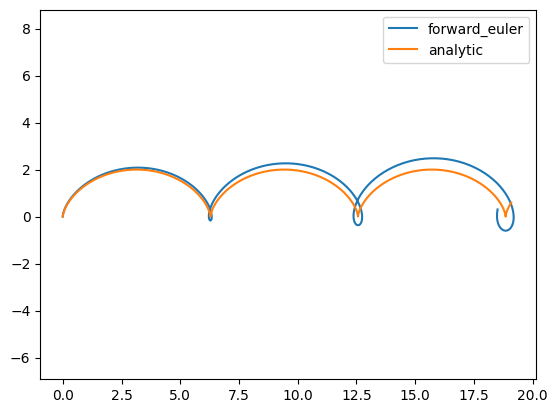

In [93]:
num_time: int = 400
total_time: float = 20
state0, time_array = initialize_parameters(num_time = num_time, total_time = total_time)

method: callable = forward_euler

history, _ = evolution(state0, num_time, total_time, method=method)
plt.plot(history[0, :], history[1, :], label=method.__name__)
plt.plot(*cycloid_analytic(time_array), label = 'analytic')

plt.axis('equal')
plt.legend()
plt.show()


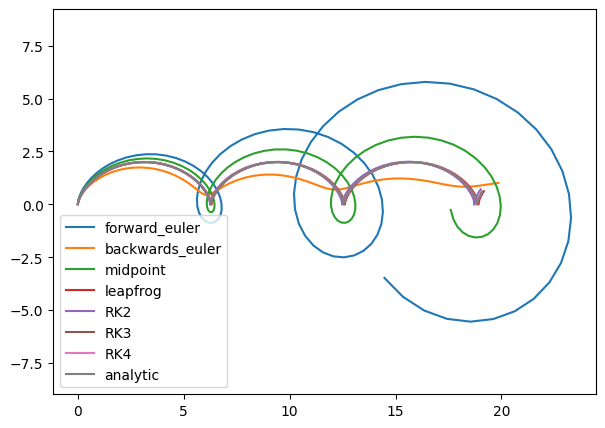

In [94]:
num_time: int = 100
total_time: float = 20

state0, time_array = initialize_parameters(num_time = num_time, total_time = total_time)
methods: list[callable] = [forward_euler, backwards_euler, midpoint, leapfrog, RK2, RK3, RK4]

plt.figure(figsize=(7, 5))
for idx, method in enumerate(methods):
    history, _ = evolution(state0, num_time, total_time, method=method)
    plt.plot(history[0, :], history[1, :], label=method.__name__)

plt.plot(*cycloid_analytic(time_array), label = 'analytic')

plt.axis('equal')
plt.legend()
plt.show()


In [95]:
methods: list[callable] = [forward_euler, backwards_euler, midpoint, leapfrog, RK2, RK3, RK4]
num_time_array: np.ndarray = (10**np.linspace(1, 5, 30)).astype(int)
error_array: np.ndarray = np.zeros([len(num_time_array), len(methods)])

total_time: float = 1

for tidx, num_time in enumerate(num_time_array): # loop over different number of time steps
    state0, time_array = initialize_parameters(total_time = total_time, num_time = num_time)
    for midx, method in enumerate(methods): # loop over different methods
        history, error = evolution(state0, num_time, total_time, method=method)
        error_array[tidx, midx] = error


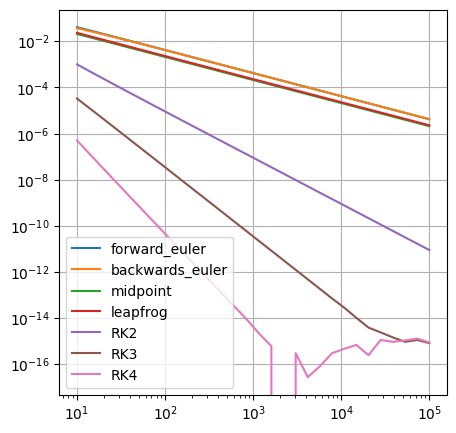

In [96]:
plt.figure(figsize=(5, 5))
for midx, method in enumerate(methods):
    plt.plot(num_time_array, error_array[:, midx], label=method.__name__)
plt.yscale('log')
plt.xscale('log')
plt.grid('on')
plt.legend()

In [7]:
list_int : list[int] = [1, 2, 3, 4, 5]
list_str : list[str] = ['a', 'b', 'c', 'd', 'e']
list_func : list[callable] = [forward_euler, backwards_euler, midpoint, leapfrog, RK2, RK3, RK4]
list_intstr : list[int, str] = [1, 'a', 2, 'b', 3, 'c', 4, 'd', 5, 'e']

In [8]:
def add_one(x: int) -> int:
    return x + 1
def add_two(x: int) -> int:
    return x + 2
def add_three(x: int) -> int:
    return x + 3

functions : callable = [add_one, add_two, add_three]
functions_str : list[str] = ['add_one', 'add_two', 'add_three']

for f in functions:
    print(f(21))
    # print name of functions
    print(f.__name__)

22
add_one
23
add_two
24
add_three


## GOT code

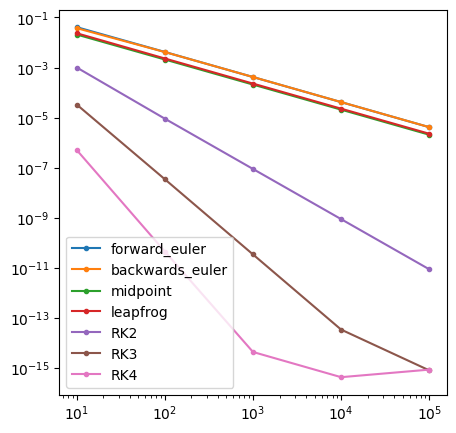

In [44]:
import matplotlib.pyplot as plt
import numpy as np
step_array : np.ndarray = np.array([10,100,1000,10000,100000], dtype=int)

state0 = np.array([0,0,0,0],dtype=float)
total_time = 1
method_func: list[callable] = [forward_euler, backwards_euler, midpoint, leapfrog, RK2, RK3, RK4]
error_array = np.zeros([len(step_array), len(method_func)], dtype=float)

for midx, method in enumerate(method_func) :
   for tidx, num in enumerate(step_array):

      history0 = np.zeros([len(state0), num])
      history, error = evolution(state0, num, total_time, history0, method=method)
      error_array[tidx, midx] = error

plt.figure(figsize=(5, 5))
for midx, method in enumerate(method_func):
    plt.plot(step_array, error_array[:, midx], '.-', label=method.__name__)
plt.legend()
plt.yscale('log')
plt.xscale('log')

In [78]:
import matplotlib.pyplot as plt
import numpy as np
methods : list[str] =['forward_euler', 'backward_euler','mid_point','leapfrog', 'RK3', 'RK4']
step_array : np.ndarray = np.array([10,100,1000,10000,100000])
# step_array : np.ndarray = (10**np.linspace(1, 5, 30)).astype(int)

# Define Parameters

def set_initial_conditions():
   # Number of time steps to simulate
   total_time: float = 1. #เวลาทั้งหมด
   #num_steps: int = 100
   s0=np.array([0.,0.])
   v0=np.array([0.,0.])
   state0=np.concatenate([s0,v0])
   return state0, total_time

# field parameters
E = 1
B = 1
omega=np.array([0,0,B])
sigma=np.array([0,E,0])

def lorentz(velo):
   acc = np.array([velo[1] * B, E - velo[0] * B])
   return acc

def deri(s):
   deri= np.concatenate([s[2:],lorentz(s[2:])])
   return deri

def leapfrog(state: np.ndarray, interval: float) -> np.ndarray:
    En = qm * E * np.array([0, 1, 0], dtype=float)
    Bn = qm * B * np.array([0, 0, 1], dtype=float)

    v_old = np.concatenate([state[2:], [0]])
    A = Bn * interval / 2
    C = v_old + En * interval + np.cross(v_old, Bn) * interval / 2
    v_new = (- np.cross(A, C) + A * np.dot(A, C) + C) / (1 + np.dot(A, A))

    state[2:] = v_new[:2] # update velocity
    state[:2] += v_new[:2] * interval # update position
    return state

# def leapfrog(s, dt) :
#    v_old= s[2:]
#    A=omega*dt/2
#    C=v_old+dt*(sigma+np.cross(v_old,omega)/2)
#    v_new= (-np.cross(A,C)+A*(np.dot(A,C))+C)/(1+np.dot(A,A))
#    s0_new=s[:2]+v_new*dt
#    s_new=np.concatenate([s0_new,v_new])
#    return s_new
# def RK4(s, dt):
#    k1=dt*deri(s)
#    s1=s+k1/2
#    k2=dt*deri(s1)
#    s2=s+k2/2
#    k3=dt*deri(s2)
#    s3=s+k3
#    k4=dt*deri(s3)
#    s_new=s+(k1+2*k2+2*k2+k4)/6
#    return s_new

# def RK3(state: np.ndarray, interval: float) -> np.ndarray:
#     k1 = interval * deriv(state)
#     k2 = interval * deriv(state + k1/2)
#     k3 = interval * deriv(state + 2 * k2 - k1)
#     state += (k1 + 4 * k2 + k3) / 6
#     return state

def analytic(time_array: np.ndarray) -> np.ndarray:
   R = E / (qm * B**2)
   omega = qm * B
   xt= R * (omega * time_array - np.sin(omega * time_array))
   yt= R * (1 - np.cos(omega * time_array))
   return xt, yt

def anymethods(state0: np.array, total_time: float, num_step: int, methods: str):
   dt: float = total_time / num_step
   state=state0.copy()
   if methods == 'forward_euler' :
       state += deri(state)*dt
   if methods =='backward_euler' :
       state_prime = state+deri(state)*dt
       state += deri(state_prime)*dt
   if methods =='mid_point' :
       state_prime = state+deri(state)*dt
       state += ((deri(state_prime)+deri(state))/2)*dt
   if methods == 'leapfrog' :
       state = leapfrog(state, dt)
   if methods == 'RK3' :
       state = RK3(state, dt)
   if methods == 'RK4' :
       state = RK4(state, dt)
   return state
   
state0, total_time = set_initial_conditions()
# method_func: list[callable] = [forward_euler, backwards_euler, midpoint, leapfrog, RK2, RK3, RK4]
error_array = np.zeros([len(step_array), len(methods)])

for midx, method in enumerate(methods) :
   for tidx, num in enumerate(step_array):
      state = state0.copy()
      for _ in range(num):
         state = anymethods(state,total_time, num, methods=method)
      state_final = state

      # history0 = np.zeros([len(state0), num])
      # print(history0.shape)
      # history, error = evolution(state0, num, total_time, history0, method=method)

      error_array[tidx, midx] = np.abs(state_final[0] - analytic(total_time)[0])
      # error_array[tidx, midx] = error
      

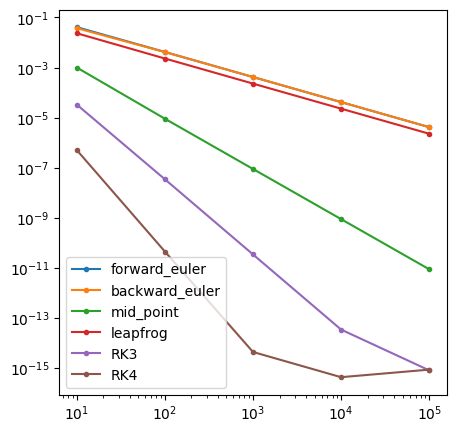

In [79]:
plt.figure(figsize=(5, 5))
for midx, method in enumerate(methods):
    plt.plot(step_array, error_array[:, midx], '.-', label=method)
plt.legend()
plt.yscale('log')
plt.xscale('log')